Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26 

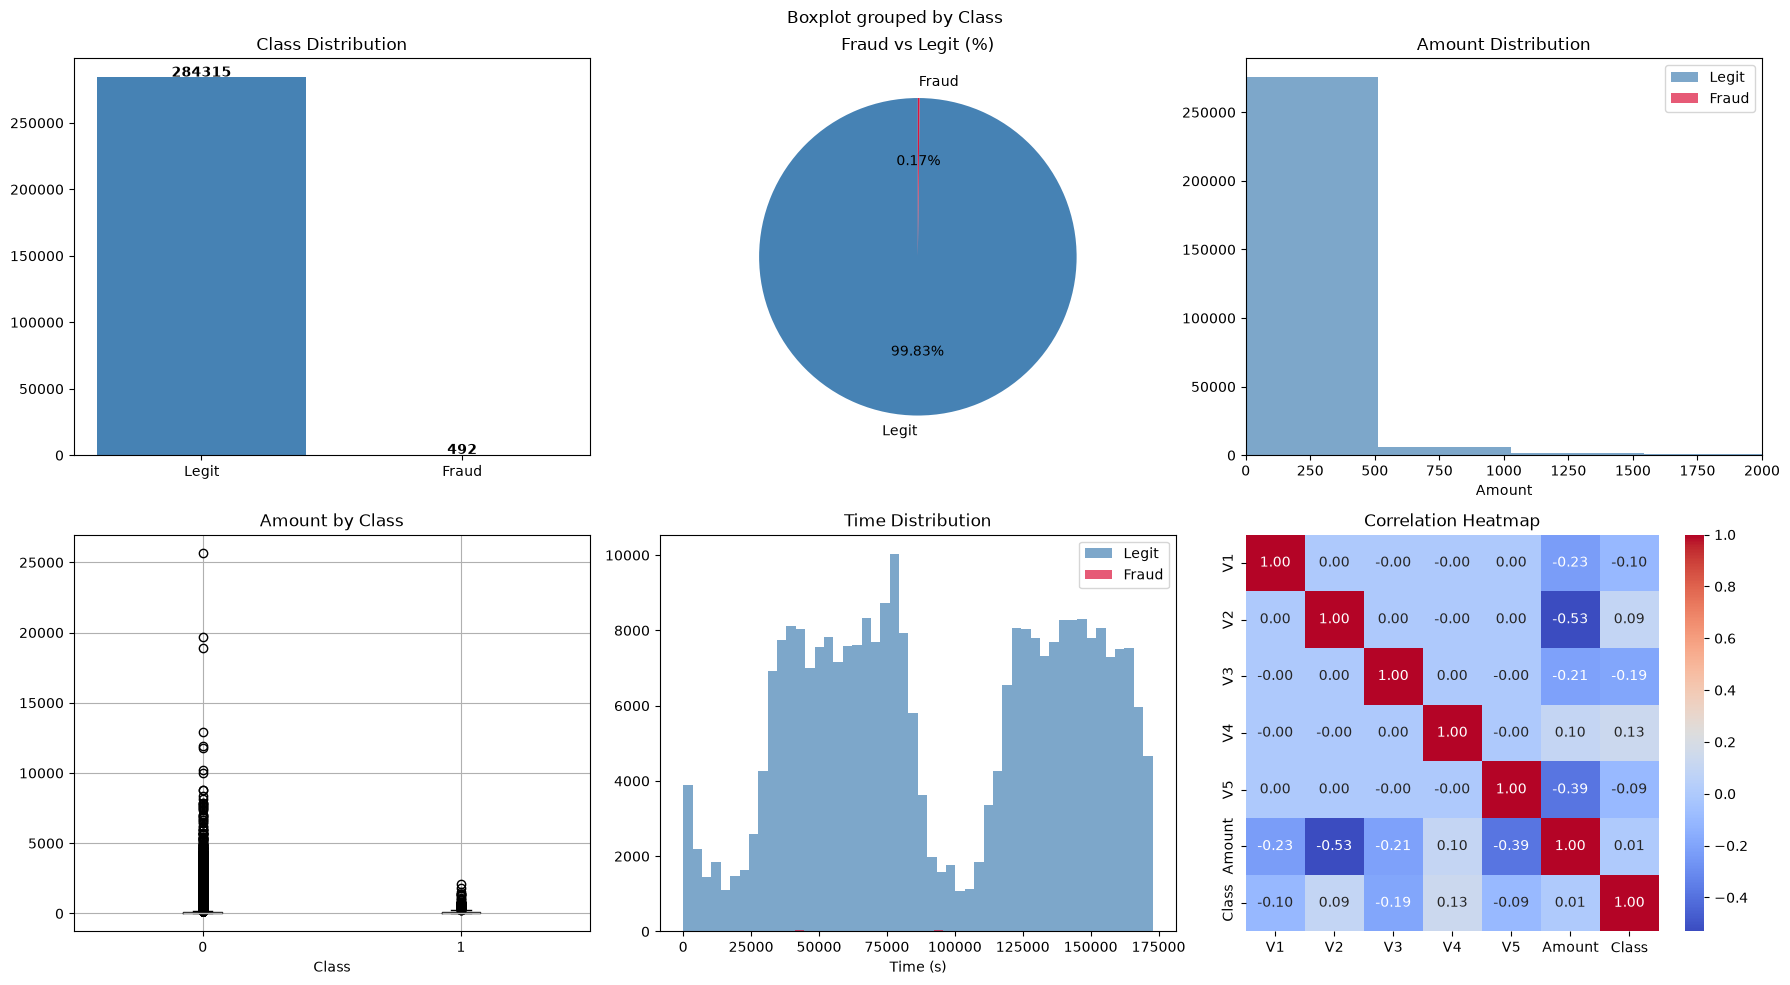

Outliers: 31904 | Lower: -101.75 | Upper: 184.51


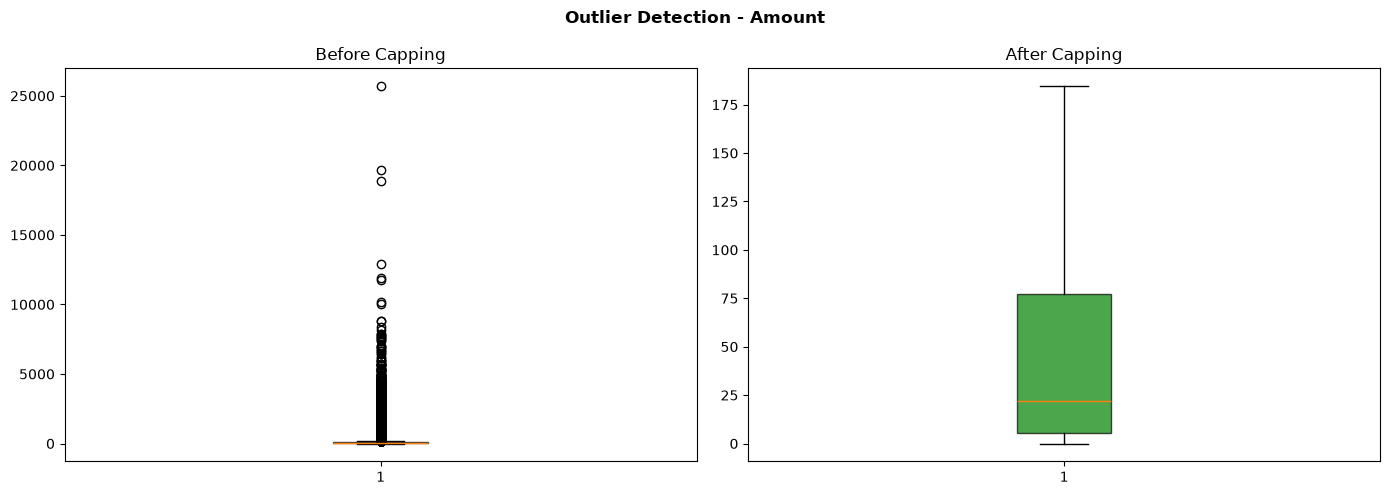

Duplicates removed: 1081
Features: 22
After SMOTE — Legit: 226602 | Fraud: 226602
Training Logistic Regression... Acc: 97.32% | ROC-AUC: 0.9665 | CV: 0.9901
Training Random Forest... Acc: 99.95% | ROC-AUC: 0.9495 | CV: 1.0000
Training Decision Tree... Acc: 99.77% | ROC-AUC: 0.8727 | CV: 0.9982
Training Naive Bayes... Acc: 97.65% | ROC-AUC: 0.9484 | CV: 0.9542
Training XGBoost... Acc: 99.90% | ROC-AUC: 0.9789 | CV: 1.0000
              Model Accuracy ROC-AUC CV-AUC Avg Precision
Logistic Regression   97.32%  0.9665 0.9901        0.6720
      Random Forest   99.95%  0.9495 1.0000        0.7963
      Decision Tree   99.77%  0.8727 0.9982        0.2985
        Naive Bayes   97.65%  0.9484 0.9542        0.0827
            XGBoost   99.90%  0.9789 1.0000        0.8001

Best Model: XGBoost (ROC-AUC: 0.9789)
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.66      0.78      0.71        95

    accuracy            

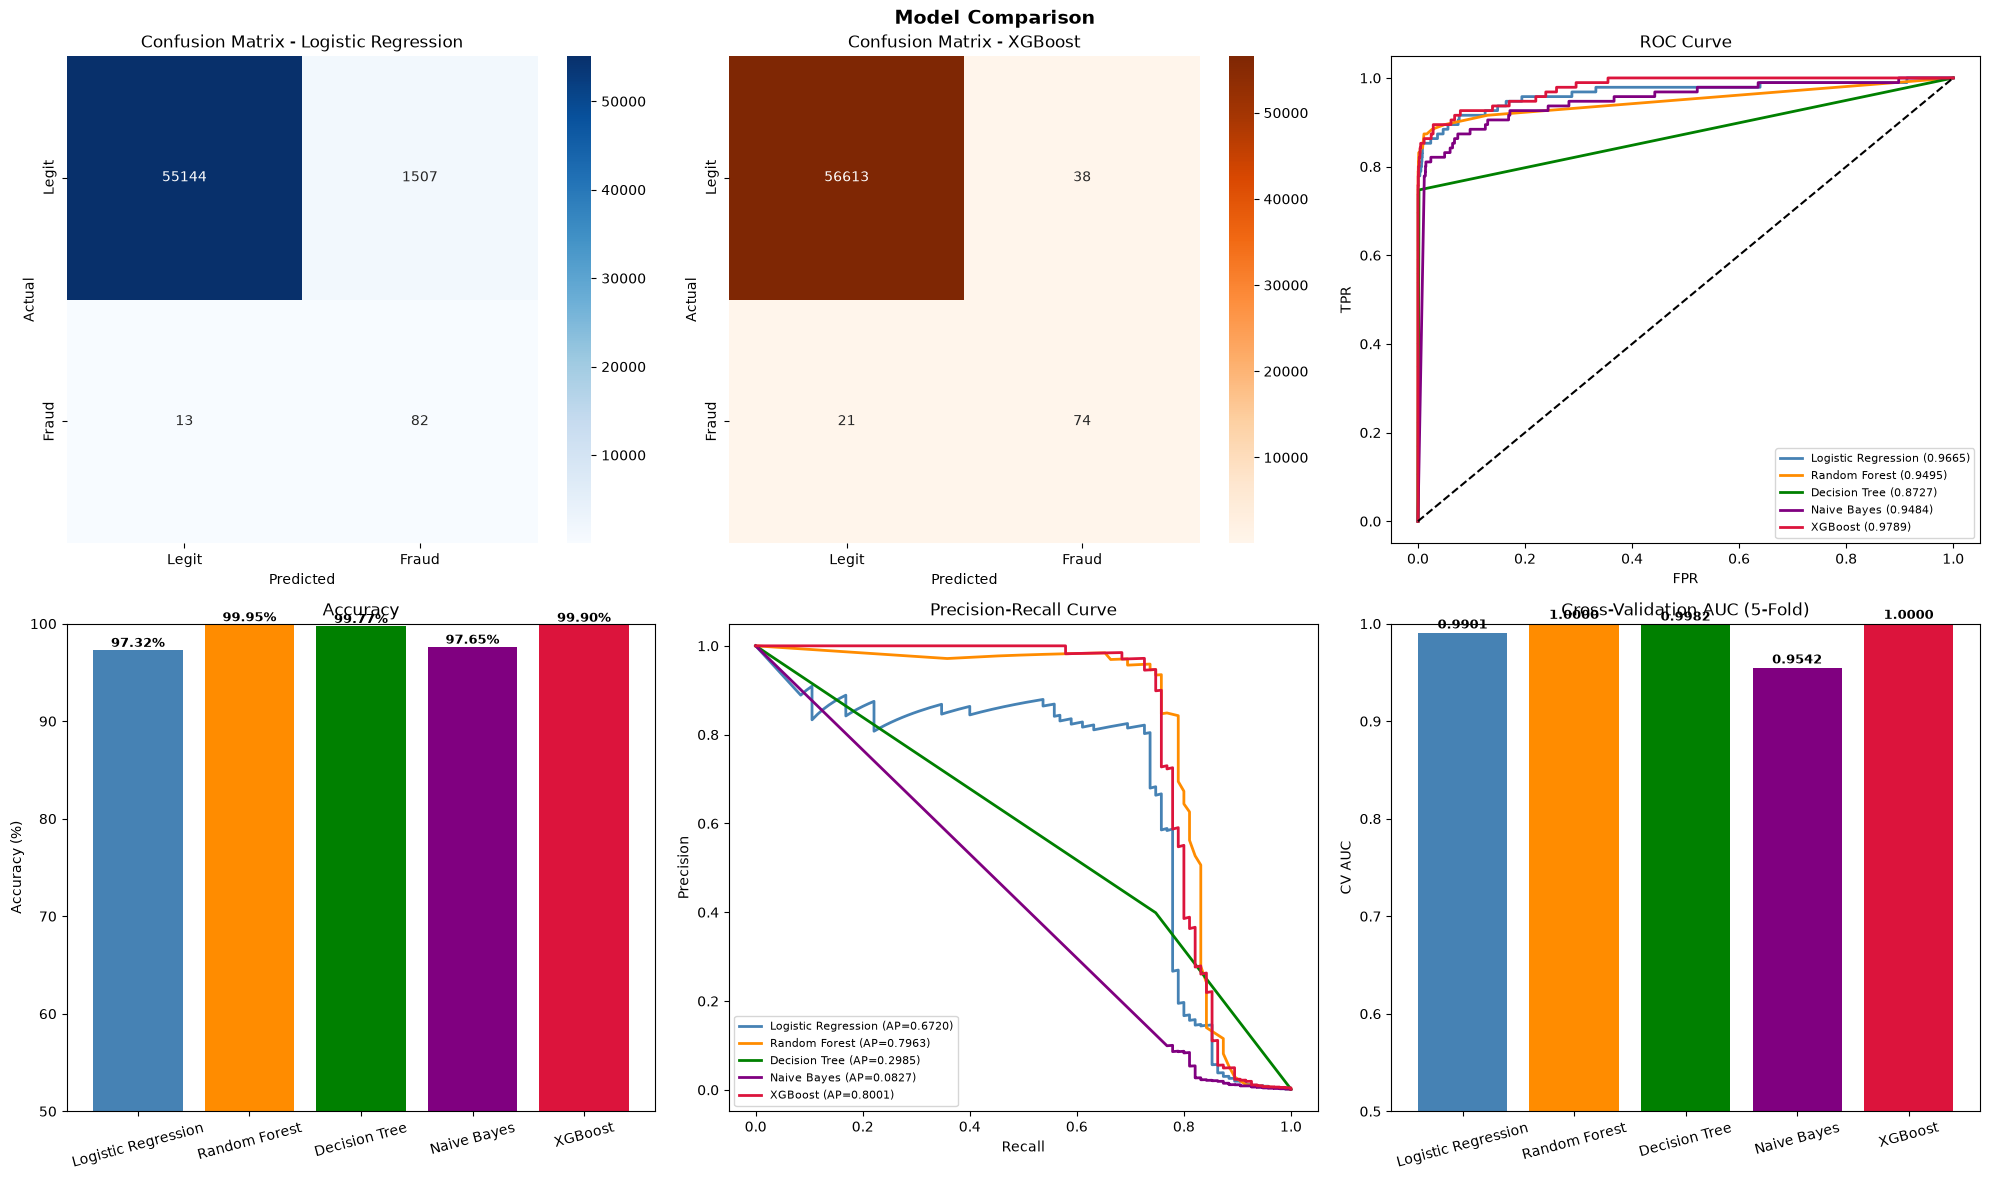

Done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

df = pd.read_csv(r"C:\Users\Yasee\Downloads\creditcard.csv")
print(f"Shape: {df.shape}")
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())
counts = df['Class'].value_counts()
print(f"Legit: {counts[0]} | Fraud: {counts[1]} ({counts[1]/len(df)*100:.4f}%)")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA - Credit Card Fraud Detection", fontsize=16, fontweight='bold')
axes[0,0].bar(['Legit','Fraud'], counts.values, color=['steelblue','crimson'])
axes[0,0].set_title('Class Distribution')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v+500, str(v), ha='center', fontweight='bold')
axes[0,1].pie(counts.values, labels=['Legit','Fraud'], autopct='%1.2f%%', colors=['steelblue','crimson'], startangle=90)
axes[0,1].set_title('Fraud vs Legit (%)')
for cls, col, lbl in [(0,'steelblue','Legit'),(1,'crimson','Fraud')]:
    axes[0,2].hist(df[df['Class']==cls]['Amount'], bins=50, alpha=0.7, color=col, label=lbl)
axes[0,2].set(title='Amount Distribution', xlabel='Amount', xlim=(0,2000))
axes[0,2].legend()
df.boxplot(column='Amount', by='Class', ax=axes[1,0])
axes[1,0].set_title('Amount by Class')
for cls, col, lbl in [(0,'steelblue','Legit'),(1,'crimson','Fraud')]:
    axes[1,1].hist(df[df['Class']==cls]['Time'], bins=50, alpha=0.7, color=col, label=lbl)
axes[1,1].set(title='Time Distribution', xlabel='Time (s)')
axes[1,1].legend()
sns.heatmap(df[['V1','V2','V3','V4','V5','Amount','Class']].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches='tight')
plt.show()

Q1, Q3 = df['Amount'].quantile(0.25), df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
print(f"Outliers: {len(df[(df['Amount']<lower)|(df['Amount']>upper)])} | Lower: {lower:.2f} | Upper: {upper:.2f}")
fig2, ax2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Outlier Detection - Amount", fontweight='bold')
ax2[0].boxplot(df['Amount'], patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
ax2[0].set_title('Before Capping')
df['Amount'] = df['Amount'].clip(lower=lower, upper=upper)
ax2[1].boxplot(df['Amount'], patch_artist=True, boxprops=dict(facecolor='green', alpha=0.7))
ax2[1].set_title('After Capping')
plt.tight_layout()
plt.savefig("outlier_plots.png", dpi=150, bbox_inches='tight')
plt.show()

before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df)}")
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df.drop(['Amount', 'Time'], axis=1, inplace=True)

df['Hour'] = (df['Time_scaled'].abs() * 24).astype(int) % 24
df['Amount_per_sec'] = df['Amount_scaled'] / (df['Time_scaled'].abs() + 1)
df['V1_V2_interaction'] = df['V1'] * df['V2']
corr_target = df.corr()['Class'].abs().sort_values(ascending=False)
low_corr = [f for f in corr_target[corr_target < 0.01].index if f != 'Class']
if low_corr:
    df.drop(columns=low_corr, inplace=True)
print(f"Features: {df.shape[1] - 1}")

X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)
print(f"After SMOTE — Legit: {sum(y_train_sm==0)} | Fraud: {sum(y_train_sm==1)}")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
}

results = {}
for name, model in models.items():
    print(f"Training {name}...", end=" ")
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    cv = cross_val_score(model, X_train_sm, y_train_sm, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    results[name] = {
        "model": model, "pred": y_pred, "prob": y_prob,
        "acc": accuracy_score(y_test, y_pred),
        "roc": roc_auc_score(y_test, y_prob),
        "cv": cv,
        "ap": average_precision_score(y_test, y_prob)
    }
    print(f"Acc: {results[name]['acc']*100:.2f}% | ROC-AUC: {results[name]['roc']:.4f} | CV: {cv:.4f}")

print(pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [f"{results[n]['acc']*100:.2f}%" for n in results],
    "ROC-AUC": [f"{results[n]['roc']:.4f}" for n in results],
    "CV-AUC": [f"{results[n]['cv']:.4f}" for n in results],
    "Avg Precision": [f"{results[n]['ap']:.4f}" for n in results]
}).to_string(index=False))

best_name = max(results, key=lambda n: results[n]['roc'])
best_model = results[best_name]['model']
print(f"\nBest Model: {best_name} (ROC-AUC: {results[best_name]['roc']:.4f})")
print(classification_report(y_test, results[best_name]['pred'], target_names=['Legit','Fraud']))

with open("best_model.pkl", "wb") as f:
    pickle.dump({"model": best_model, "name": best_name, "features": list(X.columns)}, f)
print("Saved: best_model.pkl")

colors = ['steelblue', 'darkorange', 'green', 'purple', 'crimson']
model_names = list(results.keys())

fig3, axes3 = plt.subplots(2, 3, figsize=(20, 12))
fig3.suptitle("Model Comparison", fontsize=14, fontweight='bold')

for i, name in enumerate(["Logistic Regression", best_name]):
    cm = confusion_matrix(y_test, results[name]["pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if i==0 else 'Oranges',
                xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'], ax=axes3[0,i])
    axes3[0,i].set(title=f'Confusion Matrix - {name}', xlabel='Predicted', ylabel='Actual')

for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res["prob"])
    axes3[0,2].plot(fpr, tpr, color=colors[i], lw=2, label=f'{name} ({res["roc"]:.4f})')
axes3[0,2].plot([0,1],[0,1],'k--')
axes3[0,2].set(title='ROC Curve', xlabel='FPR', ylabel='TPR')
axes3[0,2].legend(fontsize=8)

accs = [results[n]["acc"]*100 for n in model_names]
bars = axes3[1,0].bar(model_names, accs, color=colors)
axes3[1,0].set(title='Accuracy', ylabel='Accuracy (%)', ylim=(50,100))
axes3[1,0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, accs):
    axes3[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')

for i, (name, res) in enumerate(results.items()):
    prec, rec, _ = precision_recall_curve(y_test, res["prob"])
    axes3[1,1].plot(rec, prec, color=colors[i], lw=2, label=f'{name} (AP={res["ap"]:.4f})')
axes3[1,1].set(title='Precision-Recall Curve', xlabel='Recall', ylabel='Precision')
axes3[1,1].legend(fontsize=8)

cvs = [results[n]["cv"] for n in model_names]
bars3 = axes3[1,2].bar(model_names, cvs, color=colors)
axes3[1,2].set(title='Cross-Validation AUC (5-Fold)', ylabel='CV AUC', ylim=(0.5,1.0))
axes3[1,2].tick_params(axis='x', rotation=15)
for bar, v in zip(bars3, cvs):
    axes3[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("model_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done.")